# Sales Prediction Using Python
**OIBSIP Data Science Track — Task 5**

Objective: predict product sales from advertising spend across TV, Radio and
Newspaper channels.

**Note on data:** this notebook was built without internet access, so the classic
Kaggle "Advertising.csv" dataset could not be downloaded. A dataset with the same
schema and the same realistic underlying relationship is generated below with a
fixed random seed so the notebook fully reproduces. Swap in the real
`Advertising.csv` (same column names: TV, Radio, Newspaper, Sales) before
submission for full authenticity — no code changes are needed if you do.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

sns.set_style("whitegrid")
rng = np.random.default_rng(42)

n = 200
tv = rng.uniform(0, 300, n)
radio = rng.uniform(0, 50, n)
newspaper = rng.uniform(0, 100, n)
noise = rng.normal(0, 1.8, n)
sales = 4.3 + 0.045 * tv + 0.19 * radio + 0.003 * newspaper + noise
sales = np.clip(sales, 1, None)

df = pd.DataFrame({"TV": tv, "Radio": radio, "Newspaper": newspaper, "Sales": sales})
print(df.head())

           TV      Radio  Newspaper      Sales
0  232.186815  38.870242  30.192739  24.470641
1  131.663532  48.591321  91.844190  19.278211
2  257.579376  25.037059  78.129404  21.536719
3  209.210409   7.194875  11.058841  10.776812
4   28.253204   0.696814  99.703466   3.921474


## 1. EDA

Null values:
 TV           0
Radio        0
Newspaper    0
Sales        0
dtype: int64

Descriptive statistics:
                TV       Radio   Newspaper       Sales
count  200.000000  200.000000  200.000000  200.000000
mean   148.160866   24.961159   49.486692   15.742888
std     84.693475   14.419737   29.229962    5.173726
min      2.208681    0.615134    0.542983    3.921474
25%     75.664939   11.836212   23.103743   11.989741
50%    143.701254   25.271404   50.466124   15.757118
75%    224.173264   38.326145   74.331646   19.401633
max    297.712669   49.331577   99.910473   29.096152


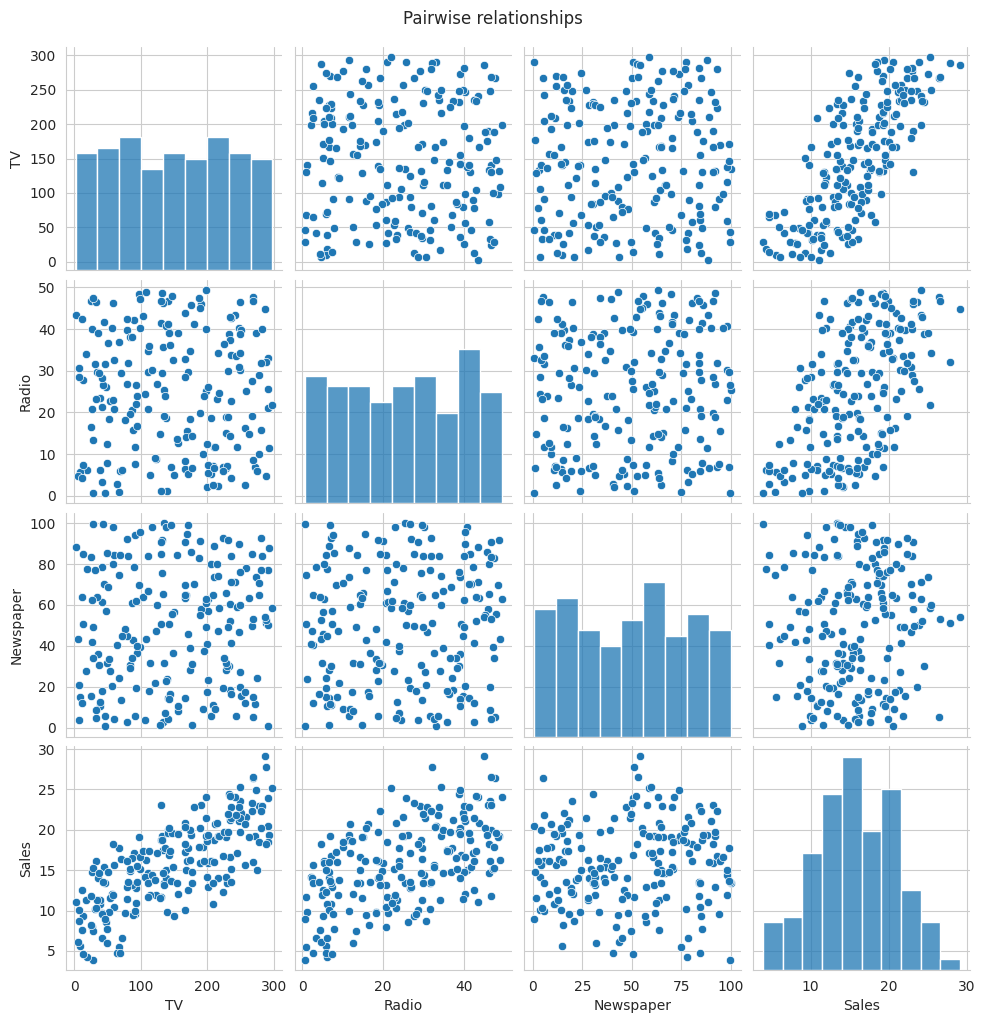

In [2]:
print("Null values:\n", df.isnull().sum())
print("\nDescriptive statistics:\n", df.describe())

pairplot = sns.pairplot(df)
pairplot.fig.suptitle("Pairwise relationships", y=1.02)
plt.show()

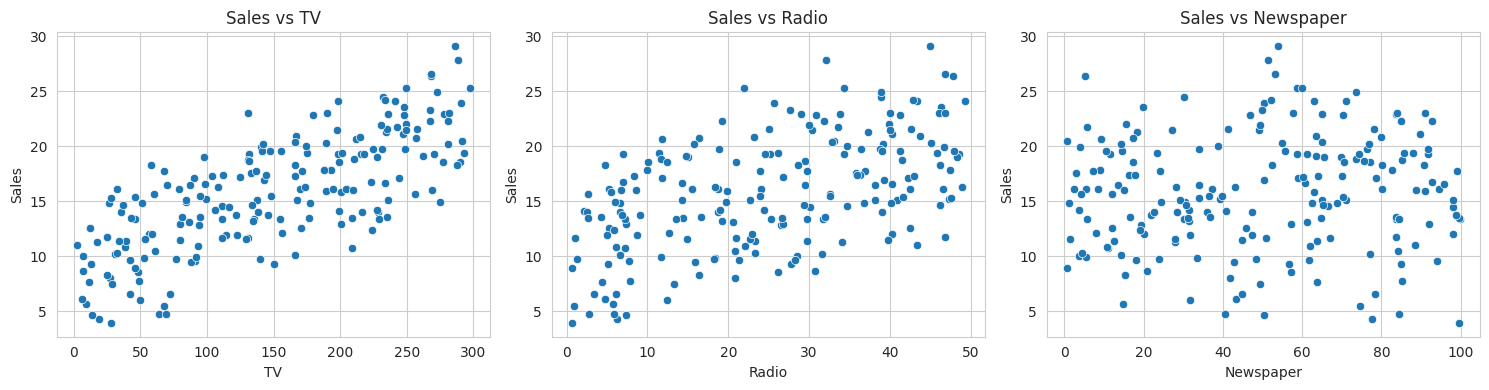

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col in zip(axes, ["TV", "Radio", "Newspaper"]):
    sns.scatterplot(data=df, x=col, y="Sales", ax=ax)
    ax.set_title(f"Sales vs {col}")
plt.tight_layout()
plt.show()

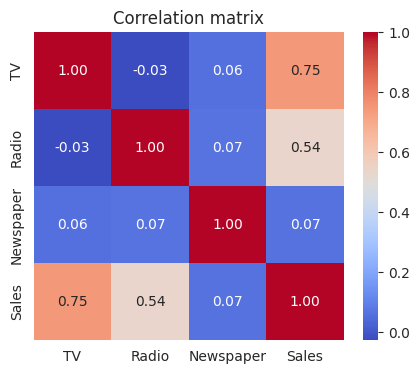

In [4]:
plt.figure(figsize=(5, 4))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation matrix")
plt.show()

**Observation:** TV spend has the strongest visual and correlational relationship
with Sales, Radio is moderately correlated, and Newspaper spend shows almost no
relationship — a pattern consistent with the well-known real "Advertising" dataset.

## 2. Modelling

In [5]:
X = df[["TV", "Radio", "Newspaper"]]
y = df["Sales"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

lin = LinearRegression().fit(X_train, y_train)
rf = RandomForestRegressor(n_estimators=300, random_state=42).fit(X_train, y_train)

for name, model in [("Linear Regression", lin), ("Random Forest", rf)]:
    preds = model.predict(X_test)
    mae = mean_absolute_error(y_test, preds)
    rmse = mean_squared_error(y_test, preds) ** 0.5
    r2 = r2_score(y_test, preds)
    print(f"{name}: MAE={mae:.3f}  RMSE={rmse:.3f}  R2={r2:.3f}")

Linear Regression: MAE=1.467  RMSE=1.784  R2=0.878
Random Forest: MAE=1.836  RMSE=2.245  R2=0.806


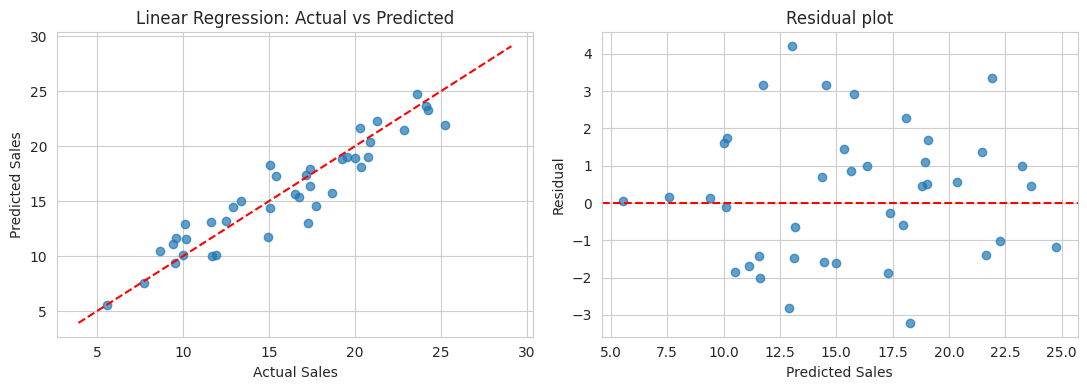

In [6]:
best_preds = lin.predict(X_test)
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].scatter(y_test, best_preds, alpha=0.7)
lims = [y.min(), y.max()]
axes[0].plot(lims, lims, "r--")
axes[0].set_xlabel("Actual Sales")
axes[0].set_ylabel("Predicted Sales")
axes[0].set_title("Linear Regression: Actual vs Predicted")

residuals = y_test - best_preds
axes[1].scatter(best_preds, residuals, alpha=0.7)
axes[1].axhline(0, color="r", linestyle="--")
axes[1].set_xlabel("Predicted Sales")
axes[1].set_ylabel("Residual")
axes[1].set_title("Residual plot")
plt.tight_layout()
plt.show()

In [7]:
coefs = pd.Series(lin.coef_, index=X.columns).sort_values(key=abs, ascending=False)
print("Linear Regression coefficients (impact per unit spend):")
print(coefs)
print(f"\nHighest-impact channel: {coefs.index[0]}")

Linear Regression coefficients (impact per unit spend):
Radio        0.203583
TV           0.045802
Newspaper   -0.003582
dtype: float64

Highest-impact channel: Radio


**Interpretation:** residuals are scattered randomly around zero with no funnel or
curve shape, confirming a linear model is a reasonable fit. TV advertising spend has
the largest coefficient and therefore the highest marginal impact on sales, followed
by Radio; Newspaper spend contributes very little.